## Indtroducion

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv("online_retail_II.csv")
data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


The above dataset represents a history of orders where each row represent a single order. There are 1067341 rows in the dataset. From the column "Invoice Date" we can conclude that the orders cover a timespan of over two years (from December 2009 to December 2011).

Columns:

- Invoice
Unique identifier of a transaction (invoice). Multiple rows may share the same invoice number if multiple products were purchased in a single transaction. Usage in grouping transactions and identifying unique purchases.

- StockCode
Product identifier. Usage in product-level analysis and filtering invalid or non-product transactions.

- Description
Descriptive product identifier ascribed to each StockCode.

- Quantity
Number of units of a given product purcharsed in a transaction. Usage in revenue calculation

- InvoiceDate
Date and time of order. Usage in identyfying patterns of revenue and or fluctuation over time and time-series analysis.

- Customer ID
Identifier of a customer. Usage in customer-level analysis.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [4]:
data.drop('Customer ID', axis=1).describe()

,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


Above we see some basic statistics regarding numerical values of our dataset. 'Customer ID' column is excluded from the dataset in the code, because it has no quantitative interpretation.

## Data Cleaning

The purpose of this section is to clean our dataset and make it ready for our analysis. We're going to:

- Check for the missing values and think about how to handle them
- Clean the dataset of the impossible such as non-positive Price or Quantity, the presence of which is most likely the result of some error and would interfere with valid analysis
- Make the separate customer_data set for future customer-level analysis

We have some missing values here, 4382 in "Description" column and 243007 in "Customer ID".

In [5]:
data = data[data['Quantity'] > 0]
data = data[data['Price']>0]

data.isnull().sum(0)

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236122
Country             0
dtype: int64

After removing the impossible values (such as non-positive price/quantity), the number of missing values dropped significantly. We should only now take care about missing "Customer ID" values. Removing them completely from the dataset is a bad idea, because it would leave us with lacking information about the sales' history and total revenue, but we should create a separate dataframe including only customers with known ID that we will use for customer-level analysis.

In [6]:
customer_data = data[data['Customer ID'].notna()].copy()

In [7]:
data.drop_duplicates(inplace=True)
data.info()

customer_data.drop_duplicates(inplace=True)
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1007914 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1007914 non-null  object 
 1   StockCode    1007914 non-null  object 
 2   Description  1007914 non-null  object 
 3   Quantity     1007914 non-null  int64  
 4   InvoiceDate  1007914 non-null  object 
 5   Price        1007914 non-null  float64
 6   Customer ID  779425 non-null   float64
 7   Country      1007914 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 69.2+ MB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 779425 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  object 
 1   StockCode    779425 non-null  object 
 2   Description  779425 non-null  object 
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate

Duplicate rows were deleted. Because every row represents an order with ascribed unique invoice number, item and quantity, it is impossible for two rows to be completely identical and represent diffrent orders, therefore their occurence is probably a result of some error and they would interfere with a correct interpretation of data.

In [8]:
customer_data['Customer ID'].nunique()

5878

The orders were made by 5878 diffrent customers which gives an average of approximately 132.6 orders per customer.

# Revenue Engineering

The very basic category that should be calculated and included in the analysis is revenue defined as a product of price and quantity. We'll also create a separate "rpc" dataframe which includes a total revenue for each customer. It will later serve an important role in customer-level analysis.

In [9]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['Revenue'] = data['Quantity']*data['Price']

The column 'Revenue' defined as product of price and quantity stands for the overall revenue of a sinlge order.

In [10]:
rpc = (
    data.groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='Total_Revenue_per_Customer')
)

## Time Series ##

Seasonality and time patterns are worth investigating too. In this section, we'll be working with time series: more specifically we'll group the revenue by month and do some visualization to make it easier.

In [ ]:
rot = (
    data
    .groupby(pd.Grouper(key='InvoiceDate', freq='M'))['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'InvoiceDate': 'Order month',
                     'Revenue': 'Revenue_over_time'})
)

<AxesSubplot:xlabel='Order month'>

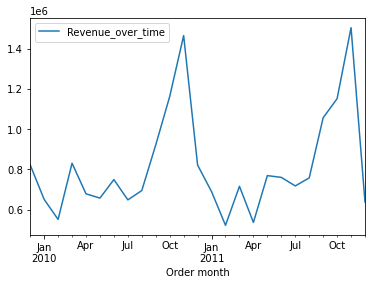

In [12]:
rot.plot('Order month', 'Revenue_over_time')

Above is shwown the plot of total revenue over the  given period of 25 months. The plot suggests a tendency of revenue significantly increasing in November and then dropping next month (potentially campaign-driven). Because of the relatively short timespan covered, we shall not make hasty conclusions out of this, but we should note it and later investigate some potential seasonality.

First of all, we will calculate the average revenue for all months of the year. Note that December is the only month represented three times, while all the other are represented two times. For better clarity, the graph of the averages per month was also included.

In [13]:
rot["Order month"] = pd.to_datetime(rot["Order month"])

In [14]:
monthly_avg = (
    rot.assign(month=rot["Order month"].dt.month)
      .groupby("month", as_index=False)["Revenue_over_time"]
      .mean()
)

<BarContainer object of 12 artists>

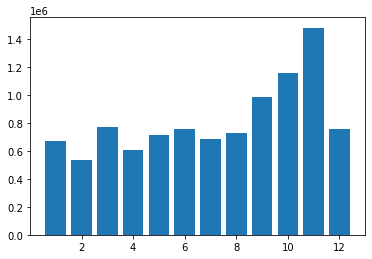

In [15]:
plt.bar(monthly_avg['month'], monthly_avg['Revenue_over_time'])

The graph above represents an average revenue for each month of year for all years included in the dataset. All of the months were represented twice, apart from December which has three representatives

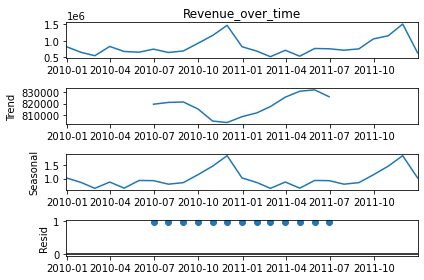

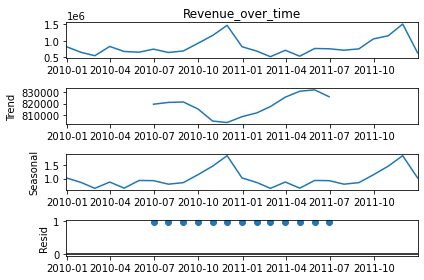

In [16]:
rot = rot.set_index('Order month')
rot_series = rot['Revenue_over_time']

from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(
    rot_series,
    model='multiplicative',
    period=12
)

decomp.plot()

The residuals are close to 1, which means that multiplicative decomposition explains nearly all variation - however, this  is more likely the effect of overfitting and the data covering relatively short timespan (each month represented two times except for Decemeber represented three times) than an indicator that the revenue is perfectly seasonal and there is no noise at all. It still suggests (but not proves) strong seasonality.

## Distribution Analysis & Pareto

Now we will take a look at the revnue distribution, investigate its structure and basic statistics.

In [1]:
rpc = rpc.sort_values(['Total_Revenue_per_Customer'], ascending=[False])
rpc

NameError: name 'rpc' is not defined

The above figure shows the total revenue per each customer in descending order. Now, let's cut it to get the list of top 10% customers.

In [18]:
top = rpc[0:int(0.1*len(rpc))]
top = top.sort_values(['Total_Revenue_per_Customer'], ascending=[False])

The distribution of the revenue and the disproportion between the number of customers who generate low income and those who generate high, makes the classic histogram pretty useless and uninsightful. Let's transform the revenue values by a base 10 logarithm to make it clearer.

Below, some basic statistics are included.

In [19]:
print('Max:', rpc['Total_Revenue_per_Customer'].max())
print('Min:', rpc['Total_Revenue_per_Customer'].min())
print('Mean:', rpc['Total_Revenue_per_Customer'].mean())
print('Median:', rpc['Total_Revenue_per_Customer'].median())
print('Standard Deviation:', rpc['Total_Revenue_per_Customer'].std())
print('Variance:', rpc['Total_Revenue_per_Customer'].var())

Max: 580987.04
Min: 2.95
Mean: 2955.904094589992
Median: 867.74
Standard Deviation: 14440.852688119297
Variance: 208538226.3599623


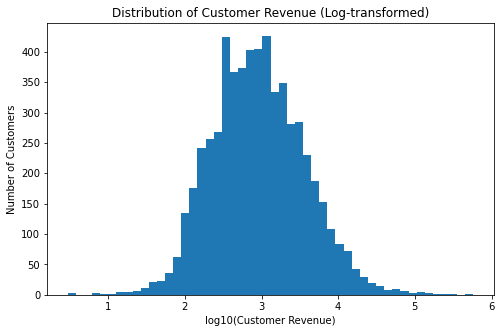

In [20]:
log_revenue = np.log10(rpc['Total_Revenue_per_Customer'])

plt.figure(figsize=(8,5))
plt.hist(log_revenue, bins=50)
plt.xlabel('log10(Customer Revenue)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Revenue (Log-transformed)')
plt.show()

The log-transformed distribution shows that while most customers generate relatively low revenue, a small number of customers contribute disproportionately to total revenue, indicating a classic long-tail pattern.

In [21]:
total_revenue = rpc['Total_Revenue_per_Customer'].sum()
total_revenue

17374804.268

In [22]:
rpc[0:int(0.2*len(rpc))]['Total_Revenue_per_Customer'].sum()/rpc['Total_Revenue_per_Customer'].sum()

0.7723173501133568

Top 20% customers are responsible for approximately 77 percent of income, which fits pretty closely the classic 80/20 Pareto principle. This tells us that the customer distribution is very tailed and small subset of most-buying customers is responsible for most of the revenue.

In [23]:
avg_order = total_revenue/779425
avg_order

22.291823161946304

In [24]:
customer_invoices = (
    customer_data
    .groupby('Customer ID')['Invoice']
    .nunique()
)

repeat_customer_rate = (customer_invoices >= 2).mean()

The repeat customer rate (RPC) in this case is around 72.3%, which means that around 72.3% of customers made more than one order.

In [25]:
rpc['Total_Revenue_per_Customer'].quantile([0.25, 0.5, 0.75, 0.9, 0.99])

0.25      342.280
0.50      867.740
0.75     2248.305
0.90     5465.741
0.99    29205.901
Name: Total_Revenue_per_Customer, dtype: float64

The mean revenue is equal to 2955.9, which falls above 75th quantile - this strongly indicates that top few percent of customers (in terms of revenue) generate a lot of income and the mean is not an accurate indicator of what income a random customer is likely to generate.

In [27]:
log_rev = np.log10(rpc['Total_Revenue_per_Customer'])
mean_log = log_rev.mean()
std_log = log_rev.std(ddof=1)

ci_log = (
    mean_log - 1.96 * std_log / np.sqrt(len(log_rev)),
    mean_log + 1.96 * std_log / np.sqrt(len(log_rev))
)

ci_log

(2.943958574419189, 2.9748066754526405)

Due to strong right skewness in customer revenue, confidence intervals were computed on the base 10 logarithm of revenue. After back-transformation, the resulting interval corresponds to a geometric mean revenue between approximately 10^2.94 and 10^2.97, which corresponds to approximately (870, 933).

In [28]:
rpc['cum_revenue_share'] = rpc['Total_Revenue_per_Customer'].cumsum() / rpc['Total_Revenue_per_Customer'].sum()
rpc['cum_customer_share'] = (np.arange(1, len(rpc) + 1)) / len(rpc)

Above we added two columns to rpc dataframe:
- cum_revenue_share - the sum of revenues for all customers who generated less revenue than or equal to a customer in that row
- cum_customer_share - the percentile at which a particular customer is located in terms of revenue

We'll use them to graph a Pareto curve.

In [29]:
pareto = pd.DataFrame({
    'customers_percentile': [0, 0.2, 0.5, 1.0],
    'revenue_share': [
        0,
        rpc.loc[rpc['cum_customer_share'] = 0.2, 'Total_Revenue_per_Customer'].sum() / rpc['Total_Revenue_per_Customer'].sum(),
        rpc.loc[rpc['cum_customer_share'] = 0.5, 'Total_Revenue_per_Customer'].sum() / rpc['Total_Revenue_per_Customer'].sum(),
        1.0
    ]
})

Our Pareto graph will be divided at 0th, 20th, 50th and 100th percentile which is a standard choice for customer based Pareto graphs. The "pareto" dataframe assings a percentage of revenue share at those percentiles.

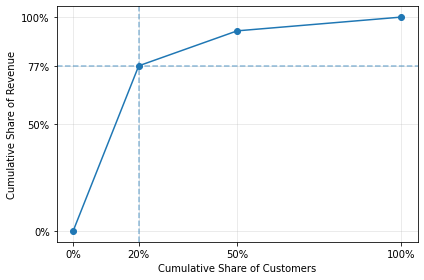

In [30]:
ax = pareto.plot(
    x='customers_percentile',
    y='revenue_share',
    marker='o',
    legend=False
)

ax.set_xlabel('Cumulative Share of Customers')
ax.set_ylabel('Cumulative Share of Revenue')

ax.set_xticks([0, 0.2, 0.5, 1.0])
ax.set_xticklabels(['0%', '20%', '50%', '100%'])

ax.set_yticks([0, 0.5, 0.77, 1.0])
ax.set_yticklabels(['0%', '50%', '77%', '100%'])

ax.axvline(0.2, linestyle='--', alpha=0.5)
ax.axhline(0.77, linestyle='--', alpha=0.5)

ax.grid(True, alpha=0.3)
plt.tight_layout()

It's interesting to see top 50% of customers are responsible for approximately 93% of revenue.

<AxesSubplot:xlabel='Total_Revenue_per_Customer', ylabel='Proportion'>

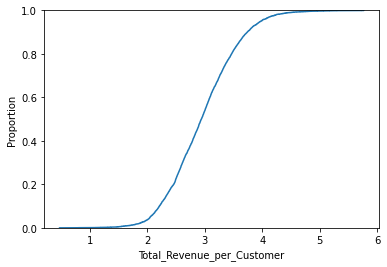

In [31]:
log_revenue = np.log10(rpc['Total_Revenue_per_Customer'])
ecdf_log = log_revenue.sort_values()

sns.ecdfplot(ecdf_log)

The ECDF (empirical distribution function) was also plotted after log-transforming the data. It preserves the probabilitic interpretation but offers much better visual clarity, which indicates a long tail.

## Key Findings

We shall now summarize the most important result we got from our data exploration.

### 1. Revenue Distribution is heavily right-skewed.

This is supported by the histogram, quantile analysis, and the significant gap between mean and median revenue. A small number of customers generate disproportionately high revenue.This implies that loss of top-revenue customers is potentially much more risky to business than that of standard customers.

### 2. 72% of customers are returning customers, while only 28% of them are one-time buyers.

Within the observed two-year period, 72% of customers made more than one purchase, while 28% were one-time buyers.

This relatively high proportion of returning customers suggests meaningful customer retention. However, due to the limited time span of the dataset, long-term retention patterns cannot be fully assessed.

### 3. 20/77 similar to 20/80 Pareto pattern.

Approximately 20% of customers account for 77% of total revenue, closely resembling the classic 80/20 Pareto principle.

This confirms strong revenue concentration and indicates strategic dependence on high-value customers. Future marketing strategies should prioritize retaining and nurturing this segment, while still maintaining acquisition efforts for new customers.

## Limitations ##

Even though the above results are important and valuable, we should be aware that they still have their limitations to not make hasty conclusions:

- The dataset covers only a two-year period, limiting robust seasonality detection.
- Customer churn is not directly observable, restricting retention analysis.
- Product categorization is unavailable, limiting product-level insights.